# Podsumowanie wyników - Klasyfikacja arytmii EKG

Porównanie różnych architektur sieci neuronowych z modelem bazowym (Random Forest)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Ustawienia stylu
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [5]:
# ========== DANE Z TRENINGU ==========

# Conv1D - najlepsza sieć (30 epok)
conv1d_train_f1 = [0.8379, 0.9056, 0.9209, 0.9251, 0.9296, 0.9325, 0.9331, 0.9344, 0.9361, 0.9366,
                   0.9388, 0.9389, 0.9400, 0.9408, 0.9408, 0.9422, 0.9427, 0.9428, 0.9432, 0.9432,
                   0.9433, 0.9429, 0.9441, 0.9445, 0.9451, 0.9453, 0.9455, 0.9455, 0.9459, 0.9454]
conv1d_val_f1 = [0.7314, 0.7689, 0.7617, 0.7776, 0.7532, 0.7680, 0.7987, 0.7861, 0.7899, 0.7633,
                 0.7862, 0.7729, 0.7879, 0.7775, 0.7913, 0.7793, 0.7747, 0.7882, 0.7729, 0.7693,
                 0.7829, 0.7903, 0.7939, 0.7295, 0.7947, 0.7991, 0.8070, 0.7758, 0.8141, 0.7807]

# LSTM - najlepsza sieć (10 epok)
lstm_train_f1 = [0.9211, 0.9683, 0.9758, 0.9796, 0.9821, 0.9839, 0.9850, 0.9862, 0.9870, 0.9877]
lstm_val_f1 = [0.7283, 0.7056, 0.7319, 0.7330, 0.6165, 0.8017, 0.6691, 0.6219, 0.6707, 0.7234]

# Dense - najlepsza sieć (10 epok - early stopping)
dense_train_f1 = [0.8145, 0.8669, 0.8771, 0.8794, 0.8812, 0.8824, 0.8851, 0.8845, 0.8851, 0.8846]
dense_val_f1 = [0.6761, 0.7358, 0.7379, 0.7168, 0.7509, 0.7439, 0.6957, 0.7275, 0.7342, 0.7050]

# Najlepsze wyniki
best_results = {
    'Conv1D': max(conv1d_val_f1),
    'LSTM': max(lstm_val_f1),
    'Dense': max(dense_val_f1),
    'Random Forest\n(Baseline)': 0.87
}

print("Najlepsze wyniki F1 Macro (walidacja):")
for name, score in best_results.items():
    print(f"  {name.replace(chr(10), ' ')}: {score:.4f}")

Najlepsze wyniki F1 Macro (walidacja):
  Conv1D: 0.8141
  LSTM: 0.8017
  Dense: 0.7509
  Random Forest (Baseline): 0.8700


## 1. Porównanie najlepszych wyników F1 Macro według typu sieci

/tmp/ipykernel_114251/2848356003.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower right')


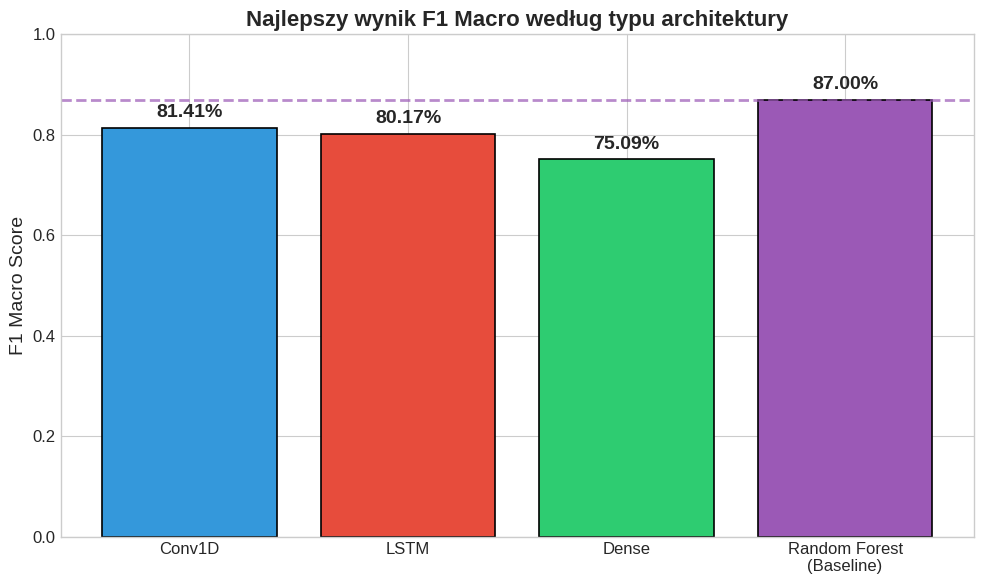

In [6]:
# Wykres słupkowy - najlepsze wyniki F1 Macro dla każdego typu sieci
fig, ax = plt.subplots(figsize=(10, 6))

models = list(best_results.keys())
scores = list(best_results.values())
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

bars = ax.bar(models, scores, color=colors, edgecolor='black', linewidth=1.2)

# Dodanie wartości nad słupkami
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.annotate(f'{score:.2%}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 5),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=14, fontweight='bold')

# Linia bazowa RF
ax.axhline(y=0.87, color='#9b59b6', linestyle='--', linewidth=2, alpha=0.7)

ax.set_ylabel('F1 Macro Score', fontsize=14)
ax.set_title('Najlepszy wynik F1 Macro według typu architektury', fontsize=16, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../figures/best_f1_by_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Krzywe uczenia - Train vs Validation F1 dla najlepszych architektur

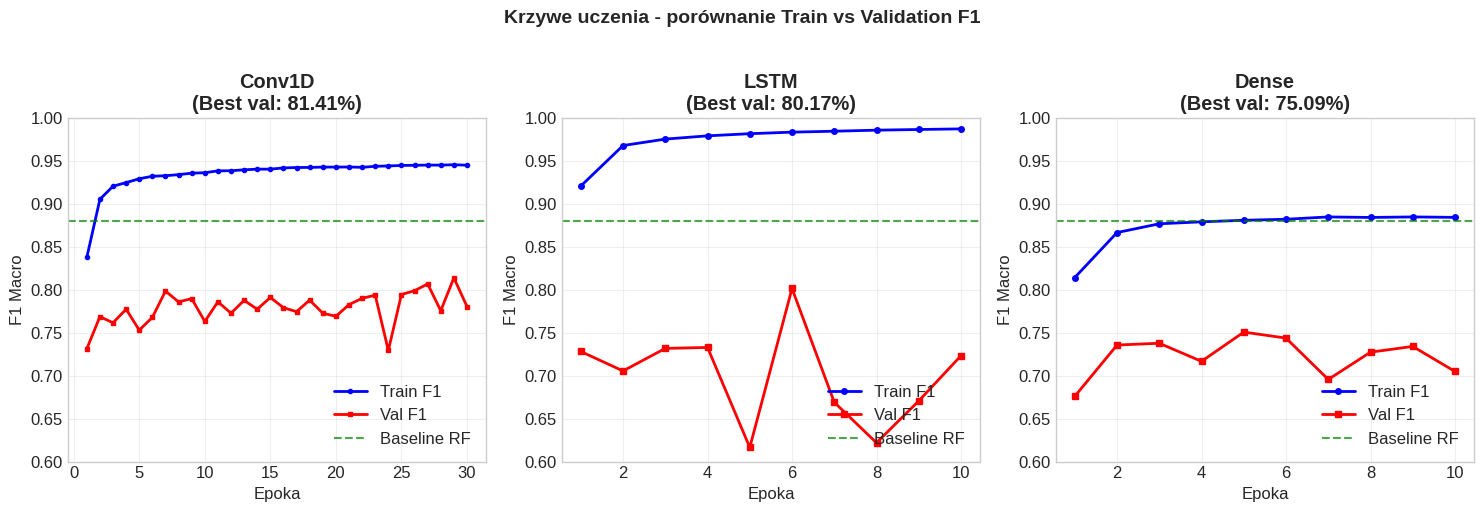

In [7]:
# Wykresy krzywych uczenia dla każdej architektury
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Conv1D
ax1 = axes[0]
epochs_conv = range(1, len(conv1d_train_f1) + 1)
ax1.plot(epochs_conv, conv1d_train_f1, 'b-', linewidth=2, label='Train F1', marker='o', markersize=3)
ax1.plot(epochs_conv, conv1d_val_f1, 'r-', linewidth=2, label='Val F1', marker='s', markersize=3)
ax1.axhline(y=0.88, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline RF')
ax1.set_xlabel('Epoka')
ax1.set_ylabel('F1 Macro')
ax1.set_title('Conv1D\n(Best val: 81.41%)', fontweight='bold')
ax1.legend(loc='lower right')
ax1.set_ylim(0.6, 1.0)
ax1.grid(True, alpha=0.3)

# LSTM
ax2 = axes[1]
epochs_lstm = range(1, len(lstm_train_f1) + 1)
ax2.plot(epochs_lstm, lstm_train_f1, 'b-', linewidth=2, label='Train F1', marker='o', markersize=4)
ax2.plot(epochs_lstm, lstm_val_f1, 'r-', linewidth=2, label='Val F1', marker='s', markersize=4)
ax2.axhline(y=0.88, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline RF')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('F1 Macro')
ax2.set_title('LSTM\n(Best val: 80.17%)', fontweight='bold')
ax2.legend(loc='lower right')
ax2.set_ylim(0.6, 1.0)
ax2.grid(True, alpha=0.3)

# Dense
ax3 = axes[2]
epochs_dense = range(1, len(dense_train_f1) + 1)
ax3.plot(epochs_dense, dense_train_f1, 'b-', linewidth=2, label='Train F1', marker='o', markersize=4)
ax3.plot(epochs_dense, dense_val_f1, 'r-', linewidth=2, label='Val F1', marker='s', markersize=4)
ax3.axhline(y=0.88, color='green', linestyle='--', linewidth=1.5, alpha=0.7, label='Baseline RF')
ax3.set_xlabel('Epoka')
ax3.set_ylabel('F1 Macro')
ax3.set_title('Dense\n(Best val: 75.09%)', fontweight='bold')
ax3.legend(loc='lower right')
ax3.set_ylim(0.6, 1.0)
ax3.grid(True, alpha=0.3)

plt.suptitle('Krzywe uczenia - porównanie Train vs Validation F1', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/learning_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Ogólne zestawienie porównawcze z modelem bazowym

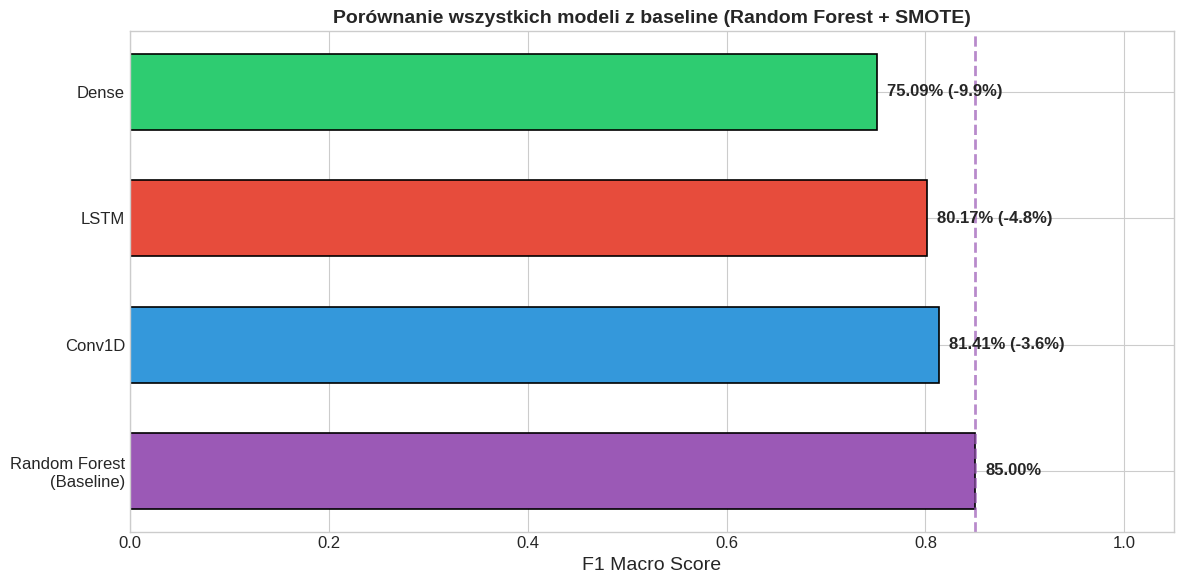


PODSUMOWANIE WYNIKÓW
Model                     F1 Macro     vs Baseline 
------------------------------------------------------------
Random Forest (Baseline)  85.00%       -           
Conv1D                    81.41%       -3.59%      
LSTM                      80.17%       -4.83%      
Dense                     75.09%       -9.91%      


In [12]:
# Zestawienie porównawcze - wykres poziomy z różnicą do baseline
fig, ax = plt.subplots(figsize=(12, 6))

models_compare = ['Random Forest\n(Baseline)', 'Conv1D', 'LSTM', 'Dense']
scores_compare = [0.85, 0.8141, 0.8017, 0.7509]
colors_compare = ['#9b59b6', '#3498db', '#e74c3c', '#2ecc71']

# Sortowanie według wyniku
sorted_data = sorted(zip(models_compare, scores_compare, colors_compare), key=lambda x: x[1], reverse=True)
models_sorted, scores_sorted, colors_sorted = zip(*sorted_data)

bars = ax.barh(models_sorted, scores_sorted, color=colors_sorted, edgecolor='black', linewidth=1.2, height=0.6)

# Dodanie wartości i różnicy do baseline
baseline = 0.85
for bar, score, model in zip(bars, scores_sorted, models_sorted):
    width = bar.get_width()
    diff = score - baseline
    diff_str = f" ({diff:+.1%})" if model != 'Random Forest\n(Baseline)' else ""
    ax.text(width + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2%}{diff_str}',
            va='center', ha='left', fontsize=12, fontweight='bold')

# Linia baseline
ax.axvline(x=0.85, color='#9b59b6', linestyle='--', linewidth=2, alpha=0.7)

ax.set_xlabel('F1 Macro Score', fontsize=14)
ax.set_title('Porównanie wszystkich modeli z baseline (Random Forest + SMOTE)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig('../figures/model_comparison_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# Podsumowanie liczbowe
print("\n" + "="*60)
print("PODSUMOWANIE WYNIKÓW")
print("="*60)
print(f"{'Model':<25} {'F1 Macro':<12} {'vs Baseline':<12}")
print("-"*60)
for model, score in zip(models_sorted, scores_sorted):
    diff = score - baseline
    diff_str = f"{diff:+.2%}" if model != 'Random Forest\n(Baseline)' else "-"
    print(f"{model.replace(chr(10), ' '):<25} {score:<12.2%} {diff_str:<12}")
print("="*60)